## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: October 10, 2026 via D2L**

## Instructions:

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

In [6]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "wasifmostofa36"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:

setwd("STAT-7110-Quality-Control//Assignments//HW2")

[1] "Repository already cloned to Colab."


## Define & Measure

### Q1: Briefly describe the purpose of this analysis

The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.Our team is to pull a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II) to determine whether the aging regulator is already producing a detectable drift.

### Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.

Our team will be monitoring the volume of the poured beraged (in ounces) and comparing the values between the Phase 1 and Phase 2 measurements in order to determine whether the aging regulator is already producing a detectable drift.

### Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts?

CUSUM and  EWMA charts are designed to catch small shifts in the process mean and draws on the entire sequence of points rather than just the latest one. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, sustained drift, rather than a sudden jump. This is why using a chart designed to catch small shifts is important.

A CUSUM and EWMA chart is more complex to implement/interpret compared to a Shewhart chart. There's no single point you can eyeball against a limit; you have to track the accumulation. It's also less obvious how to set the control parameters



## Analyze

### Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

In [19]:
## Q4 Code ##


## Load the Libraries ##
#install.packages("tidyverse")
#install.packages("readxl")
#install.packages("qcc")
library(tidyverse)
library(readxl)
library(qcc)

BustersSportsBar_PhaseI <- read_xlsx("BustersSportsBar_PhaseI.xlsx")

BustersSportsBar_PhaseI |>
  glimpse()

#Subgroup Means
BustersSportsBar_PhaseI_means <- rowMeans(BustersSportsBar_PhaseI[,-1])


#subgroup Range
BustersSportsBar_PhaseI_ranges <- apply(BustersSportsBar_PhaseI[,-1], 1, FUN = function(x){

  max(x) - min(x)

})

#process means and range
xdbar <- mean(BustersSportsBar_PhaseI_means)
print(xdbar)
sigma_hat <- sd.xbar(BustersSportsBar_PhaseI[,-1])
print(sigma_hat)

#subgroup Means and Ranges
phase1_summary <- tibble(Shift = 1:nrow(BustersSportsBar_PhaseI),
                         Mean = BustersSportsBar_PhaseI_means,
                         Range = BustersSportsBar_PhaseI_ranges)

print(phase1_summary, n = 25)

#install.packages("knitr")
#library(knitr)
#kable(phase1_summary, format = "markdown", digits = 3)


Rows: 25
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0413, 16.0675, 16.0556, 16.0424, 15.9992, 16.0585, 16.1422, 1…
$ Pour2 <dbl> 16.1330, 16.0046, 15.9970, 16.1595, 15.9692, 16.1351, 16.1080, 1…
$ Pour3 <dbl> 16.2208, 16.0829, 16.0578, 16.1260, 16.0182, 15.9698, 16.0274, 1…
$ Pour4 <dbl> 15.9739, 16.0750, 16.0771, 15.9804, 15.9541, 15.9335, 15.9874, 1…
$ Pour5 <dbl> 16.0762, 16.0499, 16.0694, 16.0306, 15.9968, 16.0919, 16.0022, 1…
[1] 16.03856
[1] 0.07718659
# A tibble: 25 × 3
   Shift  Mean  Range
   <int> <dbl>  <dbl>
 1     1  16.1 0.247 
 2     2  16.1 0.0783
 3     3  16.1 0.0801
 4     4  16.1 0.179 
 5     5  16.0 0.0641
 6     6  16.0 0.202 
 7     7  16.1 0.155 
 8     8  16.1 0.220 
 9     9  16.1 0.193 
10    10  16.0 0.0942
11    11  16.0 0.120 
12    12  15.7 0.218 
13    13  16.1 0.200 
14    14  16.1 0.199 
15    15  16.0 0.164 
16    16  16.0 0.194 
17    17  16.1 0.118 
18    18  16.1 0.149 
19    19  16.

The process mean is 16.03856
The Standard Deviation is 0.07718659

The 25 means and the 25 ranges:
| Shift|   Mean| Range|
|-----:|------:|-----:|
|     1| 16.089| 0.247|
|     2| 16.056| 0.078|
|     3| 16.051| 0.080|
|     4| 16.068| 0.179|
|     5| 15.988| 0.064|
|     6| 16.038| 0.202|
|     7| 16.053| 0.155|
|     8| 16.095| 0.220|
|     9| 16.067| 0.193|
|    10| 16.048| 0.094|
|    11| 16.046| 0.120|
|    12| 15.708| 0.218|
|    13| 16.079| 0.200|
|    14| 16.062| 0.199|
|    15| 16.006| 0.164|
|    16| 16.042| 0.194|
|    17| 16.055| 0.118|
|    18| 16.083| 0.149|
|    19| 15.996| 0.682|
|    20| 16.020| 0.091|
|    21| 16.101| 0.072|
|    22| 16.025| 0.138|
|    23| 16.092| 0.216|
|    24| 16.035| 0.223|
|    25| 16.060| 0.192|

### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

List of 11
 $ call      : language qcc(data = BustersSportsBar_PhaseI[, -1], type = "R", plot = TRUE)
 $ type      : chr "R"
 $ data.name : chr "BustersSportsBar_PhaseI[, -1]"
 $ data      : num [1:25, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 0.2469 0.0783 0.0801 0.1791 0.0641 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.18
 $ std.dev   : num 0.0772
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.38
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

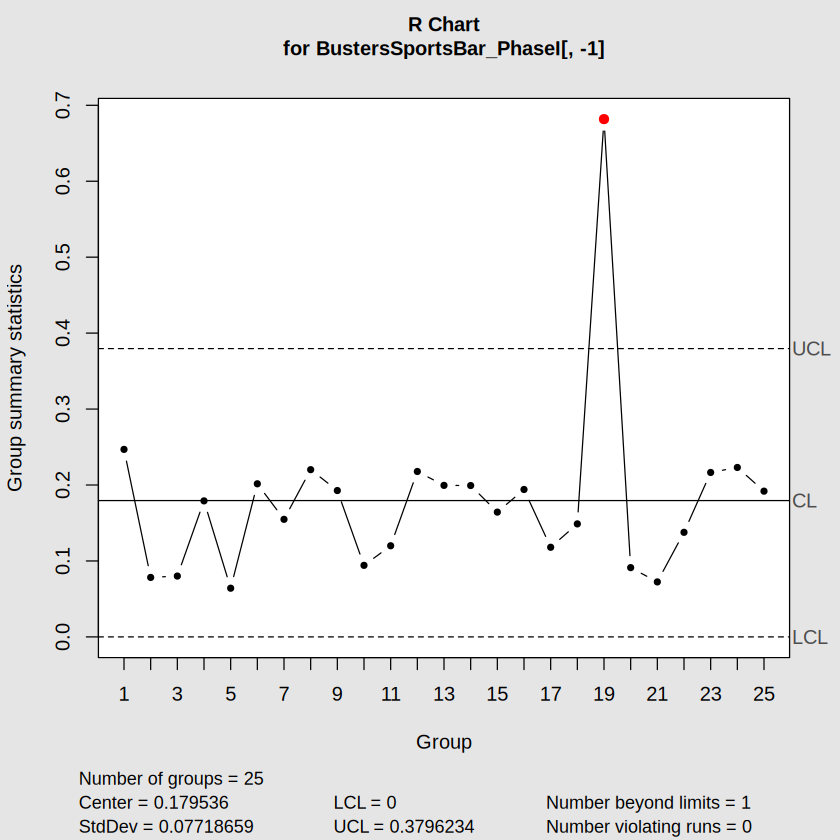

In [28]:
## Q5 Code ##

qcc(BustersSportsBar_PhaseI[,-1],type="R",plot=TRUE)

The chart does not show statistical control. Subgroup 19 is above the UCL limts. There are 0 violating runs.One potential explanation could be that a bartender may have overpoured during that specific occurance. Will omit subroup and rerun the R chart

List of 11
 $ call      : language qcc(data = PhaseI_clean[, -1], type = "R", plot = TRUE)
 $ type      : chr "R"
 $ data.name : chr "PhaseI_clean[, -1]"
 $ data      : num [1:24, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:24] 0.2469 0.0783 0.0801 0.1791 0.0641 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes     : int [1:24] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.159
 $ std.dev   : num 0.0682
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.335
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

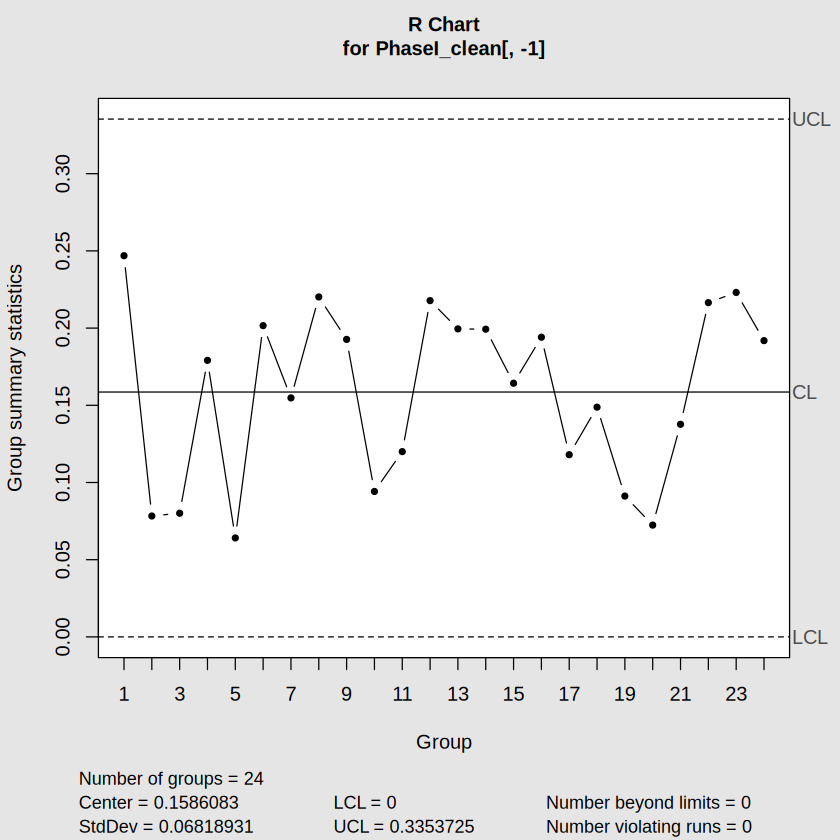

In [37]:
## Omit OOC subgroup and replot ##

PhaseI_clean <- BustersSportsBar_PhaseI |>
  filter(Shift != 19)

qcc(PhaseI_clean[,-1], type = "R", plot = TRUE)

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

List of 11
 $ call      : language qcc(data = PhaseI_clean[, -1], type = "xbar", plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "PhaseI_clean[, -1]"
 $ data      : num [1:24, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:24] 16.1 16.1 16.1 16.1 16 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes     : int [1:24] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 16
 $ std.dev   : num 0.0682
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 15.9 16.1
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

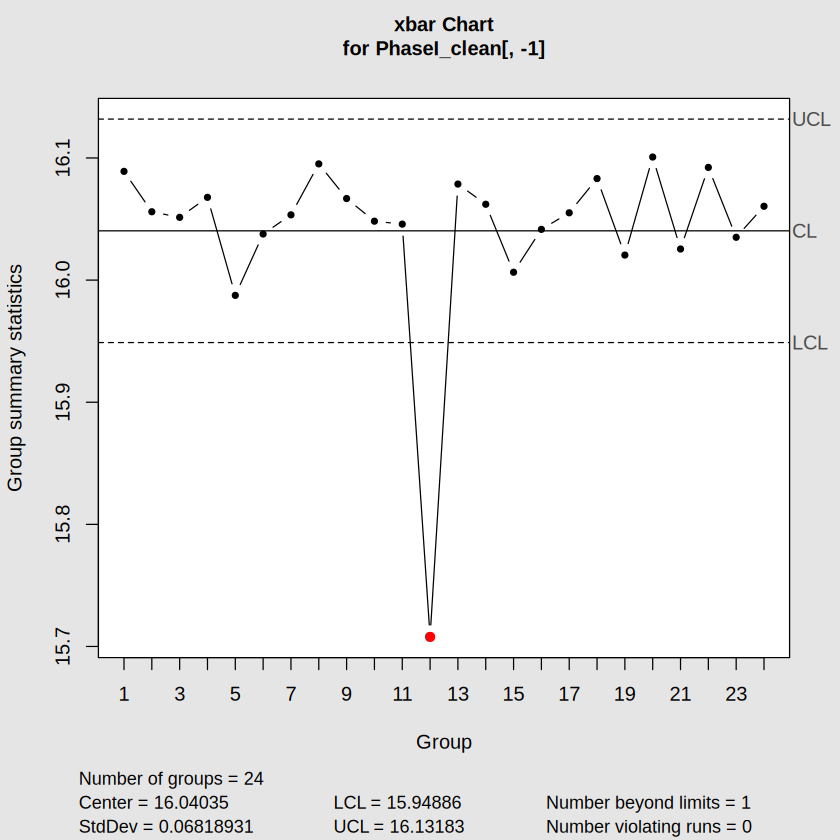

In [38]:
## Q6 Code ##

qcc(PhaseI_clean[,-1], type = "xbar", plot = TRUE)

The chart does not show statistical control. Subgroup 12 is above the UCL limts. There are 0 violating runs.One potential explanation could be that a bartender may have overpoured during that specific occurance. Will omit subroup and rerun the X chart

List of 11
 $ call      : language qcc(data = PhaseI_final[, -1], type = "xbar", plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "PhaseI_final[, -1]"
 $ data      : num [1:23, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:23] 16.1 16.1 16.1 16.1 16 ...
  ..- attr(*, "names")= chr [1:23] "1" "2" "3" "4" ...
 $ sizes     : int [1:23] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 16.1
 $ std.dev   : num 0.0671
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 16 16.1
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

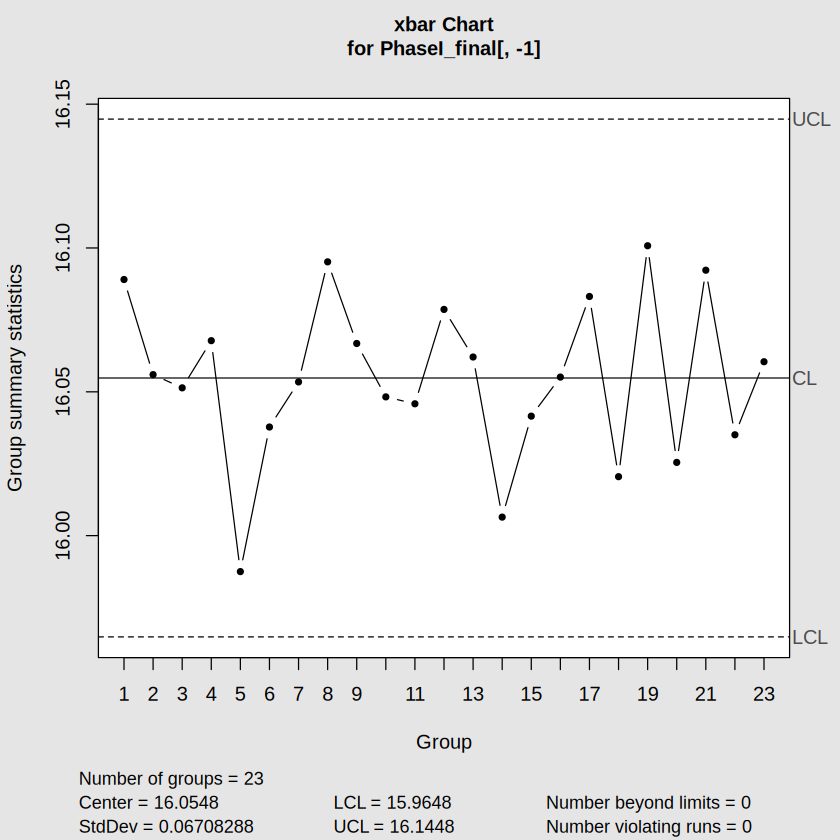

In [39]:
## Omit OOC subgroup and replot ##

PhaseI_final <- PhaseI_clean |>
  filter(Shift != 12)

qcc(PhaseI_final[,-1], type = "xbar", plot = TRUE)

### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $FNC (fraction non-conforming) ( in addition to the other PCIs.)$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

[1] 16.0548

[1] 0.06708288

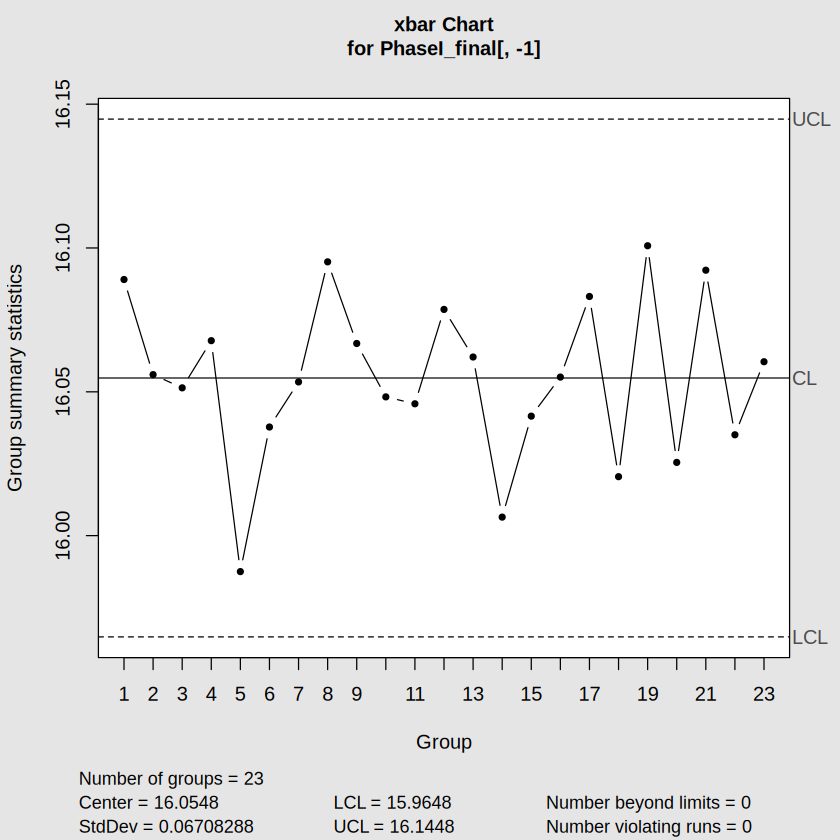

List of 11
 $ call      : language qcc(data = PhaseI_final[, -1], type = "S", plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "PhaseI_final[, -1]"
 $ data      : num [1:23, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:23] 0.0935 0.0312 0.0316 0.0733 0.0256 ...
  ..- attr(*, "names")= chr [1:23] "1" "2" "3" "4" ...
 $ sizes     : int [1:23] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.0626
 $ std.dev   : num 0.0666
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.131
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

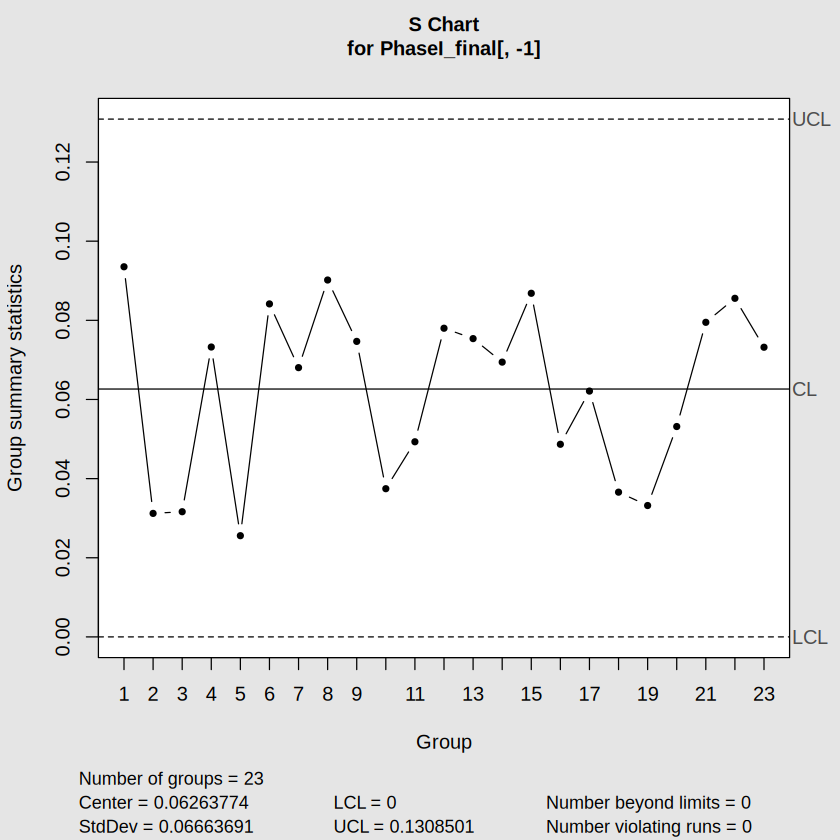


Process Capability Analysis

Call:
process.capability(object = p1x, spec.limits = c(15.8, 16.2),     target = 16, nsigmas = 3)

Number of obs = 115          Target = 16
       Center = 16.05           LSL = 15.8
       StdDev = 0.06708         USL = 16.2

Capability indices:

       Value    2.5%   97.5%
Cp    0.9938  0.8649  1.1225
Cp_l  1.2661  1.1190  1.4132
Cp_u  0.7215  0.6277  0.8152
Cp_k  0.7215  0.6098  0.8332
Cpm   0.7696  0.6521  0.8870

Exp<LSL 0%	 Obs<LSL 0%
Exp>USL 1.5%	 Obs>USL 2.6%


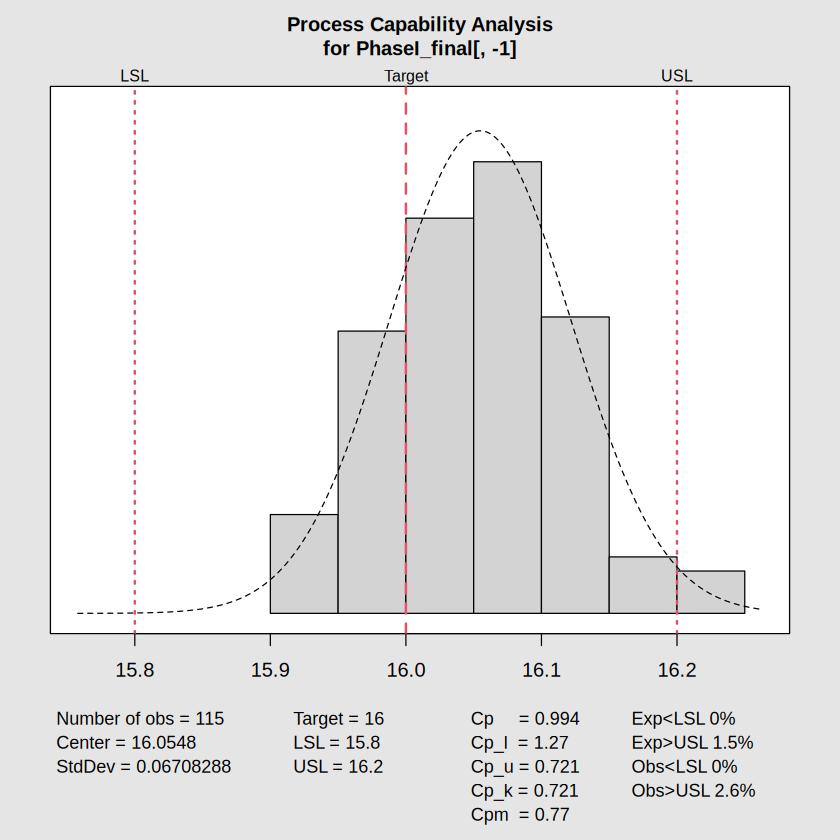

In [40]:
## Q7 Code ##

## Generate Phase I X-Bar & S Charts ##

xdbar <- mean(rowMeans(PhaseI_final[,-1]))
xdbar
sig_hat <- sd.xbar(PhaseI_final[,-1])
sig_hat

p1x <- qcc(PhaseI_final[,-1],type="xbar",std.dev=sig_hat,plot=TRUE)

qcc(PhaseI_final[,-1],type="S",plot=TRUE)


## let's calculate Cp ##

process.capability(p1x,spec.limits=c(15.80,16.20),target=16,nsigmas=3)

Cp = 0.994
Cpk = 0.721 (Cp_ = .721)
Cpm = 0.770
FNC = 0% + 1.5% = 1.5% expected. The observed figure is 2.6%.

Based on the chart, it is not capable (Cpk = 0.72 < 1), and not well-centered (running high, USL-bound).

## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q9, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

In [ ]:
## Q9 Code ##

### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

In [ ]:
## Q10 Code ##

### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

In [ ]:
## Q11 Code ##

### Q13: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?